In [1]:
import numpy as np
import time
import h5py
import pickle
import matplotlib.pyplot as plt
from scipy.stats import norm
from concurrent.futures import ProcessPoolExecutor, as_completed

from Closed_form import *
from FDM import *
from MC import *
# import os

# global var
S0 = 1.0
K = 1.0
r = 0.03
sigma = np.sqrt(0.05)
T = 1.5
BS_eta = (S0, K, r, sigma, T)
# S0, K, r, kappa, theta, xi, rho, Y0, T = Hes_eta
Hes_eta = (S0, K, r, 2, 0.05, 0.5, -0.7, 0.05, T)

# down-and-out must B < S0
B = 0.8 
if not(B < S0):
    raise ValueError("down-and-out : B should be smaller than S0")

# type : call or put
opt_type = 'put' 
if not(opt_type == 'call' or  opt_type == 'put'):
    raise ValueError("option_type must be 'call' or 'put'")

/home/enjongoopee/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# step1. generate parameter combinations
#1) BS
def generate_BS_params(n_sets, seed=None):
    if seed is not None:
        np.random.seed(seed)

    S0 = np.random.normal(loc=1.0, scale=0.2, size=n_sets)  # S0 ~ N(1, 0.2^2) Greek 계산시 delta를 구할 경우 1로 안둠.
    r = np.random.uniform(0, 0.1, n_sets)      # r ~ U(0, 0.1)
    sigma = np.random.uniform(0.001, 1, n_sets)# σ ~ U(0.001, 1)
    T = np.random.uniform(0.1, 3, n_sets)      # T ~ U(0.1, 3)
    K = 1                                      # K = 1

    params = np.stack([S0, K, r, sigma, T], axis=1)
    return params

#2) heston
def generate_heston_params(n_sets, seed=None):
    if seed is not None:
        np.random.seed(seed)

    r = np.random.uniform(0, 0.1, n_sets)      # r ~ U(0, 0.1)
    lamb = np.random.beta(2, 18, n_sets) * 20  # λ ~ Beta(2, 18) × 20
    v_bar = np.random.beta(1, 19, n_sets)      # v_bar ~ Beta(1, 19)
    epsilon = np.random.uniform(0.1, 1, n_sets)# ξ ~ U(0.1, 1)
    rho = np.random.uniform(-1, 0, n_sets)     # ρ ~ U(-1, 0)
    Y0 = np.random.beta(1, 19, n_sets)         # Y₀ ~ Beta(1, 19)
    T = np.random.uniform(0.1, 3, n_sets)      # T ~ U(0.1, 3)
        
    params = np.stack([r, lamb, v_bar, epsilon, rho, Y0, T], axis=1)
    return params

def filter_milestein(params): # milestein condition
    _, lamb, v_bar, epsilon, *_ = params.T
    mask = 4 * lamb * v_bar > epsilon**2
    return params[mask]

def generate_valid_params(n_sets, seed=None):
    raw = generate_heston_params(int(n_sets * 1.1), seed)
    filtered = filter_milestein(raw)
    
    while len(filtered) < n_sets:
        extra = generate_heston_params(n_sets)
        extra = filter_milestein(extra)
        filtered = np.vstack([filtered, extra])
    
    return filtered[:n_sets]

def min_max_normalize(data):
    return (data - data.min()) / (data.max() - data.min())

In [ ]:
#step1-1
BS_paras = generate_BS_params(n_sets=100*(2**16), seed=1234)
BS_paras_scaled = BS_paras.copy()

for col in range(5):
    if col == 0:
        BS_paras_scaled[:, col] = (BS_paras[:, col] - 1.0) / 0.2
    else:
        BS_paras_scaled[:, col] = min_max_normalize(BS_paras[:, col])

In [8]:
#step1-2 
Hes_paras = generate_valid_params(n_sets=100*(2**16), seed=1234) # 4.1초

Hes_paras_scaled = Hes_paras.copy()
for col in range(7):
    Hes_paras_scaled[:, col] = min_max_normalize(Hes_paras[:, col])

ETA_PATH = "/mnt/d/heston_eta.h5" # 10초
with h5py.File(ETA_PATH, "w") as f:
    f.create_dataset("etas", data=Hes_paras,
                     maxshape=(None, 7), chunks=(10240, 7), compression="gzip")

"""
print(f"\n파라미터 범위 확인:")
names = ['r', 'λ', 'v_bar', 'ξ', 'ρ', 'Y₀', 'T']
for i, name in enumerate(names):
    print(f"{name}: min={params[:,i].min():.4f}, max={params[:,i].max():.4f}, mean={params[:,i].mean():.4f}")
"""

'\nprint(f"\n파라미터 범위 확인:")\nnames = [\'r\', \'λ\', \'v_bar\', \'ξ\', \'ρ\', \'Y₀\', \'T\']\nfor i, name in enumerate(names):\n    print(f"{name}: min={params[:,i].min():.4f}, max={params[:,i].max():.4f}, mean={params[:,i].mean():.4f}")\n'

In [ ]:
# step2. generate path
# 1) Heston
# MC.py -> generate_heston_paths

#step2-2
ETA_PATH  = "/mnt/d/heston_eta.h5"
SAVE_PATH = "/mnt/d/heston_dataset.h5"


for i in range(9,10):
    print(i)
    with h5py.File(ETA_PATH, "r") as ef:
        Hes_paras = ef["etas"][:]  # (2**16)*100개, 여기서 target*num개 만큼씩 가져오게 해도 됨.

    target = (2**16) * 10 # 3.6h 걸림
    true = 0
    fail = 0 # 1116 + 1128 + 1114 + 1111 + 1084 + 1127 + 1143 + 1058 + 1089 + 1054
    num = i # 9까지, done : 0, 1, 2, 3, 4, 5, 6, 7, 8, 9 
    start = time.time()

    # CPU 병렬, 멀티 쓰레딩은 성능 안좋음
    N_WORKERS = 14 # 1만개 기준 = 14:207s/28:192s, 이용률 2배차이
    BATCH_SIZE = N_WORKERS * 10


    def _worker(args):
        eta, n_paths, dt = args
        return generate_heston_paths(eta, n_paths=n_paths, dt=dt)

    with h5py.File(SAVE_PATH, "a") as f, ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
        if "paths" not in f:
            f.create_dataset("paths", shape=(0, 4), maxshape=(None, 4),
                            dtype="float64", chunks=(10240, 4), compression="gzip")

        for i in range(0, target, BATCH_SIZE):
            eta_batch = Hes_paras[i + target*num : i + BATCH_SIZE + target*num]
                    
            futures = {executor.submit(_worker, (eta, 2**10, 0.001)): (i + target*num + k, eta)
                    for k, eta in enumerate(eta_batch)}

            for future in as_completed(futures):
                ori_idx, eta = futures[future]
                XT, YT, MT, mask = future.result()

                if mask:
                    rows = np.column_stack([
                        np.full(len(XT), ori_idx),
                        XT, YT, MT
                    ])
                    f["paths"].resize(f["paths"].shape[0] + len(rows), axis=0)
                    f["paths"][-len(rows):] = rows

                    true += 1
                    if true % 20000 == 0:
                        print(f"[{true}/{target}] fail: {fail}")
                else:
                    fail += 1

                if target <= true:
                    break
            else:
                continue
            break
        else:
            Hes_paras = generate_valid_params(n_sets=(target - true), seed=None)

    elapsed = time.time() - start
    print(f"done. true: {true}, fail: {fail}")
    print(f"elapsed: {elapsed:.1f}s ({elapsed/3600:.2f}h)")

9
[20000/655360] fail: 34
[40000/655360] fail: 69
[60000/655360] fail: 105
[80000/655360] fail: 126
[100000/655360] fail: 163
[120000/655360] fail: 194
[140000/655360] fail: 234
[160000/655360] fail: 259
[180000/655360] fail: 291
[200000/655360] fail: 322
[220000/655360] fail: 354
[240000/655360] fail: 382
[260000/655360] fail: 408
[280000/655360] fail: 434
[300000/655360] fail: 460
[320000/655360] fail: 483
[340000/655360] fail: 513
[360000/655360] fail: 538
[380000/655360] fail: 565
[400000/655360] fail: 599
[420000/655360] fail: 627
[440000/655360] fail: 666
[460000/655360] fail: 701
[480000/655360] fail: 743
[500000/655360] fail: 782
[520000/655360] fail: 828
[540000/655360] fail: 865
[560000/655360] fail: 895
[580000/655360] fail: 930
[600000/655360] fail: 963
[620000/655360] fail: 1000
[640000/655360] fail: 1036
done. true: 654306, fail: 1054
elapsed: 15000.2s (4.17h)


In [23]:
# 1. closed-form pricing result
closed_bs_van = BS_vanilla(BS_eta, opt_type)
closed_bs_barr = BS_barrier(BS_eta, B, opt_type)

In [24]:
# 2. MC
mc_bs_van_gpu = MC_BS_vanilla_gpu(BS_eta, n_paths=100000, type=opt_type)
mc_hes_van_gpu = MC_heston_vanilla_gpu(Hes_eta, n_paths=100000, type=opt_type)
# BS_van
# CPU vanilla(1k, 10k, 100k) = (0.042, 0.453, 4.783)
# GPU vanilla(1k, 10k, 100k) = (0.143, 0.156, 0.163)

# Hes_van
# CPU vanilla(1k, 10k, 100k) = (0.112, 1.160, 11.992)
# GPU vanilla(1k, 10k, 100k) = (0.438, 0.485, 0.54)

#start = time.time()
mc_bs_barr_gpu = MC_BS_barrier_gpu(BS_eta, B, n_paths=100000, type=opt_type)
mc_hes_barr_gpu = MC_heston_barrier_gpu(Hes_eta, B, n_paths=100000, type=opt_type)
#print(f"{time.time() - start:.3f}s")
# BS_barr
# CPU vanilla(1k, 10k, 100k) = ( , , )
# GPU vanilla(1k, 10k, 100k) = ( 0.150, 0.150, 0.155)

# Hes_barr
# CPU vanilla(1k, 10k, 100k) = ( , , )
# GPU vanilla(1k, 10k, 100k) = ( 0.45, 0.47, 0.53)

In [ ]:
#start = time.time()
#print(f"{time.time() - start:.3f}s")

In [25]:
# 3. FDM
ftcs_bs_van = FTCS_BS_vanilla(BS_eta, opt_type)
cn_bs_van = CN_BS_vanilla(BS_eta, opt_type)
cs_hes_van = CS_ADI_heston_vanilla(Hes_eta, opt_type)


ftcs_bs_barr = FTCS_BS_barrier(BS_eta, opt_type, B)
cn_bs_barr = CN_BS_barrier(BS_eta, opt_type, B)
cs_hes_barr = CS_ADI_heston_barrier(Hes_eta, opt_type, B)

0/150
1/150
2/150
3/150
4/150
5/150
6/150
7/150
8/150
9/150
10/150
11/150
12/150
13/150
14/150
15/150
16/150
17/150
18/150
19/150
20/150
21/150
22/150
23/150
24/150
25/150
26/150
27/150
28/150
29/150
30/150
31/150
32/150
33/150
34/150
35/150
36/150
37/150
38/150
39/150
40/150
41/150
42/150
43/150
44/150
45/150
46/150
47/150
48/150
49/150
50/150
51/150
52/150
53/150
54/150
55/150
56/150
57/150
58/150
59/150
60/150
61/150
62/150
63/150
64/150
65/150
66/150
67/150
68/150
69/150
70/150
71/150
72/150
73/150
74/150
75/150
76/150
77/150
78/150
79/150
80/150
81/150
82/150
83/150
84/150
85/150
86/150
87/150
88/150
89/150
90/150
91/150
92/150
93/150
94/150
95/150
96/150
97/150
98/150
99/150
100/150
101/150
102/150
103/150
104/150
105/150
106/150
107/150
108/150
109/150
110/150
111/150
112/150
113/150
114/150
115/150
116/150
117/150
118/150
119/150
120/150
121/150
122/150
123/150
124/150
125/150
126/150
127/150
128/150
129/150
130/150
131/150
132/150
133/150
134/150
135/150
136/150
137/150
138/15

In [26]:
# Total result
print(closed_bs_van, mc_bs_van_gpu, ftcs_bs_van, cn_bs_van)
print(f"{(mc_bs_van_gpu - closed_bs_van) / closed_bs_van * 100}%")
print(f"{(ftcs_bs_van - closed_bs_van) / closed_bs_van * 100}%")
print(f"{(cn_bs_van - closed_bs_van) / closed_bs_van * 100}%")

print(closed_bs_barr, mc_bs_barr_gpu, ftcs_bs_barr, cn_bs_barr)
print(f"{(mc_bs_barr_gpu - closed_bs_barr) / closed_bs_barr * 100}%")
print(f"{(ftcs_bs_barr - closed_bs_barr) / closed_bs_barr * 100}%")
print(f"{(cn_bs_barr - closed_bs_barr) / closed_bs_barr * 100}%")

print(mc_hes_van_gpu, cs_hes_van)
print(f"{(cs_hes_van - mc_hes_van_gpu) / mc_hes_van_gpu * 100}%")


print(mc_hes_barr_gpu, cs_hes_barr)
print(f"{(cs_hes_barr - mc_hes_barr_gpu) / mc_hes_barr_gpu * 100}%")


0.08594238962559853 0.08620497013751616 0.08592574698698162 0.08592499052134153
0.3055308481199367%
-0.01936487766910952%
-0.020245078514561993%
0.02709523854470053 0.010118500873780674 0.009518704566123184 0.00951805983134698
-62.65579704313132%
-64.86945648985653%
-64.87183600305086%
0.08055468240775013 0.08597330005315812
6.726632746163827%
0.005545973185794227 0.005393544679114704
-2.748453726209181%


In [ ]:
n_list    = [1000, 10000, 100000]
n_repeats = 50
results   = {n: [] for n in n_list}

for n in n_list:
    for _ in range(n_repeats):
        price = MC_heston_vanilla_gpu(Hes_eta, n_paths=n, type=opt_type)
        results[n].append(price)

# pickle은 binary로.
with open('mc_hes_van_put_results.pkl', 'wb') as f:
    pickle.dump(results, f)

In [ ]:
'''
configs = [ # vanilla_call
    dict(dS=0.01, dv=0.01, dt=0.01),  # present = dict(dS=0.01, dv=0.01, dt=0.005), dict(dS=0.01, dv=0.01, dt=0.001), = 0.129976
    dict(dS=0.005, dv=0.005, dt=0.005), # = 0.127356
    dict(dS=0.002, dv=0.002, dt=0.005), # = 0.125731, dt=0.01에서 줄여도 큰 차이 없음
    dict(dS=0.002, dv=0.002, dt=0.01), # = 0.125723
    dict(dS=0.002, dv=0.001, dt=0.01), # = 0.125134
    dict(dS=0.001, dv=0.002, dt=0.01), # = 0.125692, 메모리 10% 사용, dv 줄이는게 영향이 더 큼
    dict(dS=0.001, dv=0.001, dt=0.01), # = 0.125106
    dict(dS=0.01, dv=0.001, dt=0.01), # = 0.125122, 22s ***
    dict(dS=0.01, dv=0.0001, dt=0.01), # = 0.124491, 3m 44s *****
    dict(dS=0.001, dv=0.0001, dt=0.01), # = 0.124478, 28m, 38% 사용
    dict(dS=0.01, dv=0.00001, dt=0.01), # = 0.124395, 40m 41s
    
    dict(dS=0.0005, dv=0.0005, dt=0.01), # = 0.124748, 1step 5초
    dict(dS=0.0001, dv=0.0005, dt=0.01), # memory error
    dict(dS=0.0001, dv=0.0001, dt=0.01), # memory error
]

configs = [
    dict(dS=0.01, dv=0.01, dt=0.01), # = 0.085973
    dict(dS=0.01, dv=0.001, dt=0.01), # = 0.081119
    dict(dS=0.01, dv=0.0001, dt=0.01), # = 0.080489 *****
]
'''

for cfg in configs:
    p = CS_ADI_heston_vanilla(Hes_eta, type=opt_type, **cfg)
    print(cfg, f"→ {p:.6f}")

0/150
1/150
2/150
3/150
4/150
5/150
6/150
7/150
8/150
9/150
10/150
11/150
12/150
13/150
14/150
15/150
16/150
17/150
18/150
19/150
20/150
21/150
22/150
23/150
24/150
25/150
26/150
27/150
28/150
29/150
30/150
31/150
32/150
33/150
34/150
35/150
36/150
37/150
38/150
39/150
40/150
41/150
42/150
43/150
44/150
45/150
46/150
47/150
48/150
49/150
50/150
51/150
52/150
53/150
54/150
55/150
56/150
57/150
58/150
59/150
60/150
61/150
62/150
63/150
64/150
65/150
66/150
67/150
68/150
69/150
70/150
71/150
72/150
73/150
74/150
75/150
76/150
77/150
78/150
79/150
80/150
81/150
82/150
83/150
84/150
85/150
86/150
87/150
88/150
89/150
90/150
91/150
92/150
93/150
94/150
95/150
96/150
97/150
98/150
99/150
100/150
101/150
102/150
103/150
104/150
105/150
106/150
107/150
108/150
109/150
110/150
111/150
112/150
113/150
114/150
115/150
116/150
117/150
118/150
119/150
120/150
121/150
122/150
123/150
124/150
125/150
126/150
127/150
128/150
129/150
130/150
131/150
132/150
133/150
134/150
135/150
136/150
137/150
138/15

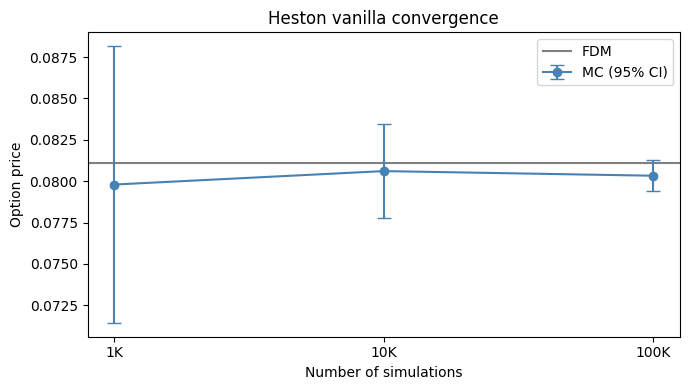

In [ ]:
fdm_price = 0.081119 #cs_hes_van
n_list    = [1000, 10000, 100000]
with open('mc_hes_van_put_results.pkl', 'rb') as f:
    results = pickle.load(f)
    
means  = [np.mean(results[n]) for n in n_list]
stds   = [np.std(results[n])  for n in n_list]
ci     = [1.96 * s for s in stds]

plt.figure(figsize=(7, 4))
plt.axhline(fdm_price, color='gray', linewidth=1.5, label='FDM')
plt.errorbar(range(len(n_list)), means, yerr=ci,
             fmt='o-', color='steelblue', capsize=5, label='MC (95% CI)')
plt.xticks(range(len(n_list)), ['1K', '10K', '100K'])
plt.xlabel('Number of simulations')
plt.ylabel('Option price')
plt.title('Heston vanilla convergence')
plt.legend()
plt.tight_layout()
#plt.savefig('hes_van_convergence.png', dpi=150)

In [ ]:
n_list    = [1000, 10000, 100000]
n_repeats = 50
results   = {n: [] for n in n_list}

for n in n_list:
    for _ in range(n_repeats):
        price = MC_heston_barrier_gpu(Hes_eta, B, n_paths=n, type=opt_type)
        results[n].append(price)

with open('mc_hes_barr_put_results.pkl', 'wb') as f:
    pickle.dump(results, f)

OutOfMemoryError: Out of memory allocating 12,000,000,000 bytes (allocated so far: 24,840,016,384 bytes).

In [ ]:
configs = [
    # call
    #dict(dS=0.01, dv=0.001, dt=0.01), # = 0.116258, 20.3s
    #dict(dS=0.01, dv=0.0001, dt=0.01), # = 0.115734, 3m 37s ***
    #dict(dS=0.001, dv=0.0001, dt=0.01), # = 0.115722, 21m 20s
    #dict(dS=0.01, dv=0.00001, dt=0.01), # = 0.115654, 44m 26s
    # put
    #dict(dS=0.01, dv=0.01, dt=0.01), # = 0.005394, 3.6s, 
    #dict(dS=0.01, dv=0.001, dt=0.01), # = 0.005213, 20.6s, 
    #dict(dS=0.01, dv=0.0001, dt=0.01), # = 0.005171, 3m 22s,
    #dict(dS=0.001, dv=0.01, dt=0.01), # = 0.005410,  
    #dict(dS=0.0001, dv=0.01, dt=0.01), # = 0.005410
    #dict(dS=0.001, dv=0.001, dt=0.01), # =0.005231
]

for cfg in configs:
    start = time.time()
    p = CS_ADI_heston_barrier(Hes_eta, type=opt_type, **cfg)
    print(f"{time.time() - start:.3f}s")
    print(cfg, f"→ {p:.6f}")

213.649s
{'dS': 0.01, 'dv': 0.0001, 'dt': 0.01} → 2.048915


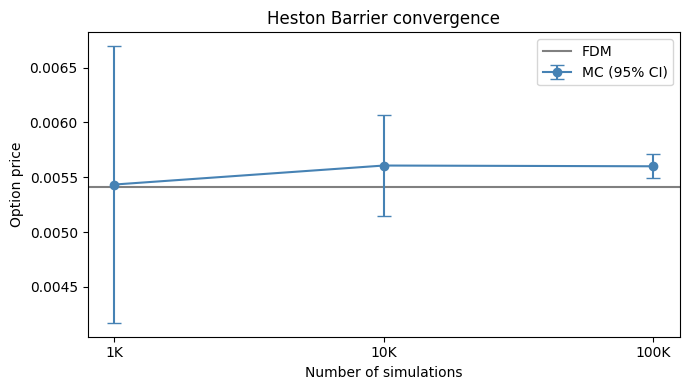

In [ ]:
fdm_price = p #cs_hes_van
n_list    = [1000, 10000, 100000]
with open('mc_hes_barr_put_results.pkl', 'rb') as f:
    results = pickle.load(f)
    
means  = [np.mean(results[n]) for n in n_list]
stds   = [np.std(results[n])  for n in n_list]
ci     = [1.96 * s for s in stds]

plt.figure(figsize=(7, 4))
plt.axhline(fdm_price, color='gray', linewidth=1.5, label='FDM')
plt.errorbar(range(len(n_list)), means, yerr=ci,
             fmt='o-', color='steelblue', capsize=5, label='MC (95% CI)')
plt.xticks(range(len(n_list)), ['1K', '10K', '100K'])
plt.xlabel('Number of simulations')
plt.ylabel('Option price')
plt.title('Heston Barrier convergence')
plt.legend()
plt.tight_layout()
#plt.savefig('hes_barr_convergence.png', dpi=150)
'''
몬테카를로 방식은 dt = n과 n+1 사이에 barrier를 건들 수 있기 때문에 FDM과 괴리가 있을 수 있다.
그래서 MC는 barrier 옵션에서 가격을 과대평가하는 경향이 있다.
'''